In [1]:
import pandas as pd
import numpy as np
import h5py

path = 'data/ca_his_raw_2019.h5'
with h5py.File(path, "r") as f:
    print(list(f.keys()))
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(name, obj.shape, obj.dtype)

    f.visititems(show)

['t']
t/axis0 (8600,) |S9
t/axis1 (105120,) int64
t/block0_items (8600,) |S9
t/block0_values (105120, 8600) float64


In [2]:
domain = pd.read_csv('data/ca_meta.csv', dtype={"ID": str})
domain.head()

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,317802,38.389811,-121.479587,3,Sacramento,I5-N,2,Mainline,N,0
1,312134,38.412564,-121.484319,3,Sacramento,I5-N,2,Mainline,N,1
2,312133,38.428630,-121.487657,3,Sacramento,I5-N,3,Mainline,N,2
3,313159,38.450246,-121.492176,3,Sacramento,I5-N,3,Mainline,N,3
4,319767,38.465539,-121.496450,3,Sacramento,I5-N,3,Mainline,N,4


In [3]:
domain_fwy = ['SR22-E','SR22-W','SR55-N','SR55-S']
domain.loc[domain['Fwy'].isin(domain_fwy), 'ID'].to_string(index=False).split('\n')

['1202590',
 '1214853',
 '1215236',
 '1202595',
 '1214869',
 '1202614',
 '1215092',
 '1202627',
 '1202648',
 '1202691',
 '1214938',
 '1214955',
 '1202705',
 '1202720',
 '1202742',
 '1202753',
 '1214988',
 '1215003',
 '1214805',
 '1202779',
 '1202785',
 '1215252',
 '1214894',
 '1202827',
 '1215017',
 '1202844',
 '1202855',
 '1215043',
 '1202885',
 '1214715',
 '1202901',
 '1212170',
 '1202921',
 '1202949',
 '1202964',
 '1202977',
 '1214881',
 '1215026',
 '1202574',
 '1202564',
 '1214854',
 '1215248',
 '1202599',
 '1214871',
 '1202610',
 '1215091',
 '1202631',
 '1202663',
 '1202676',
 '1214939',
 '1214954',
 '1202701',
 '1202724',
 '1202738',
 '1214972',
 '1214987',
 '1215002',
 '1214806',
 '1202766',
 '1202789',
 '1215250',
 '1202803',
 '1202814',
 '1215018',
 '1202840',
 '1202859',
 '1215044',
 '1202872',
 '1211641',
 '1202912',
 '1202929',
 '1202917',
 '1202938',
 '1202960',
 '1202981',
 '1214882',
 '1202993',
 '1203021',
 '1203035',
 '1203057',
 '1203071',
 '1203082',
 '1210205',
 '12

In [4]:
domain[domain['District'] == 12].drop_duplicates(['Fwy'])

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
7647,1204198,33.405160,-117.597992,12,Orange,I5-N,4,Mainline,N,7647
7754,1204193,33.404943,-117.598167,12,Orange,I5-S,4,Mainline,S,7754
7860,1202590,33.774261,-118.034947,12,Orange,SR22-E,3,Mainline,E,7860
7898,1202574,33.774686,-118.038174,12,Orange,SR22-W,3,Mainline,W,7898
7937,1203021,33.651784,-117.908497,12,Orange,SR55-N,4,Mainline,N,7937
7971,1203016,33.651901,-117.908673,12,Orange,SR55-S,3,Mainline,S,7971
8001,1211907,33.784350,-117.879424,12,Orange,SR57-N,5,Mainline,N,8001
8030,1211954,33.777415,-117.874735,12,Orange,SR57-S,2,Mainline,S,8030
8058,1210440,33.545677,-117.674552,12,Orange,SR73-N,3,Mainline,N,8058
8109,1210441,33.545627,-117.674915,12,Orange,SR73-S,3,Mainline,S,8109


In [5]:
domain.loc[domain['District'] == 12, 'Fwy'].value_counts()

Fwy
I5-N       107
I5-S       106
SR241-N     66
SR241-S     64
I405-N      58
I405-S      57
SR73-S      52
SR73-N      51
SR91-W      46
SR91-E      44
SR22-W      39
SR22-E      38
SR55-N      34
SR55-S      30
SR57-N      29
SR57-S      28
SR133-N     24
SR133-S     20
SR261-N     17
SR261-S     16
SR142-E     14
SR142-W      7
I605-N       3
I605-S       3
Name: count, dtype: int64

In [6]:
def extract_details(fwy, district = 12):
    ids = set(domain.loc[(domain['District'] == district) & domain['Fwy'].isin(fwy), 'ID'])
    with h5py.File(path, "r") as f:
        sensors_raw = [x.decode("utf-8") for x in f["t/axis0"][:]]
        sensors = []
        for i in sensors_raw:
            if i in ids:
                sensors.append(i)
        timestamps = pd.to_datetime(f['t/axis1'][:])

        return sensors, len(sensors), timestamps
d12_fwy = domain.loc[domain['District'] == 12, 'Fwy'].unique().tolist() 
domain_sensors, len_of_sensors, timestamps = extract_details(d12_fwy)
print('number of sensors:', len_of_sensors)
print('first sensors:', domain_sensors[:20])
print('first timestamps:', timestamps)

number of sensors: 953
first sensors: ['1204198', '1204211', '1204230', '1204244', '1204255', '1210908', '1204268', '1204279', '1213215', '1221232', '1204301', '1204316', '1204328', '1204340', '1204372', '1204384', '1204395', '1204409', '1210926', '1220030']
first timestamps: DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 00:05:00',
               '2019-01-01 00:10:00', '2019-01-01 00:15:00',
               '2019-01-01 00:20:00', '2019-01-01 00:25:00',
               '2019-01-01 00:30:00', '2019-01-01 00:35:00',
               '2019-01-01 00:40:00', '2019-01-01 00:45:00',
               ...
               '2019-12-31 23:10:00', '2019-12-31 23:15:00',
               '2019-12-31 23:20:00', '2019-12-31 23:25:00',
               '2019-12-31 23:30:00', '2019-12-31 23:35:00',
               '2019-12-31 23:40:00', '2019-12-31 23:45:00',
               '2019-12-31 23:50:00', '2019-12-31 23:55:00'],
              dtype='datetime64[ns]', length=105120, freq=None)


In [7]:
def get_df(sensors, timestamps, span):
    wanted = pd.Index(sensors)
    with h5py.File(path, "r") as f:
        hdf_sensors = pd.Index(x.decode("utf-8") for x in f["t/axis0"][:])
        positions = hdf_sensors.get_indexer(wanted)

        values = f['t/block0_values'][:, positions]

    df = pd.DataFrame(values, index=timestamps, columns=wanted)
    if span == 1:
        df = df.loc['2019-01-01':'2019-06-30']
    elif span == 2:
        df = df.loc['2019-07-01':'2019-12-31']
    else:
        df = df
    return df.resample('15min').mean()
df = get_df(domain_sensors, timestamps, 3)
df

,1204198,1204211,1204230,1204244,1204255,1210908,1204268,1204279,1213215,1221232,...,1221523,1221550,1221536,1221556,1219551,1202527,1202549,1219560,1202522,1202537
2019-01-01 00:00:00,8.666667,39.333333,57.666667,65.666667,59.000000,33.333333,98.000000,58.333333,57.666667,61.333333,...,101.666667,104.666667,92.666667,76.000000,51.666667,0.000000,NaN,25.666667,64.333333,58.000000
2019-01-01 00:15:00,8.000000,33.666667,73.000000,79.333333,69.333333,39.666667,100.333333,72.000000,73.000000,92.333333,...,177.666667,165.666667,121.333333,98.333333,137.333333,127.333333,NaN,55.666667,122.000000,118.000000
2019-01-01 00:30:00,5.666667,42.000000,74.333333,78.666667,68.333333,34.666667,103.333333,73.333333,74.000000,87.666667,...,255.000000,235.000000,186.333333,161.666667,183.000000,167.333333,NaN,147.333333,148.666667,137.333333
2019-01-01 00:45:00,18.333333,52.666667,79.333333,76.666667,74.333333,35.333333,107.000000,77.000000,82.666667,91.333333,...,270.333333,267.666667,217.333333,179.666667,186.000000,167.666667,NaN,169.000000,156.666667,153.666667
2019-01-01 01:00:00,58.333333,77.666667,89.333333,97.333333,95.666667,84.000000,128.666667,92.000000,96.000000,110.333333,...,280.000000,281.333333,222.000000,180.333333,141.000000,120.333333,NaN,175.333333,171.000000,163.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 22:45:00,38.333333,64.666667,68.333333,106.000000,101.333333,52.000000,86.666667,84.666667,86.666667,92.666667,...,260.333333,212.000000,141.000000,144.000000,145.666667,140.000000,135.333333,145.000000,144.000000,132.333333
2019-12-31 23:00:00,55.333333,67.666667,76.333333,116.000000,114.333333,78.333333,95.000000,97.000000,96.333333,105.000000,...,221.333333,191.666667,127.000000,130.000000,130.000000,119.333333,111.000000,47.666667,108.666667,110.333333
2019-12-31 23:15:00,19.000000,51.666667,63.666667,102.333333,102.000000,53.666667,83.000000,79.333333,84.000000,91.333333,...,225.000000,182.000000,115.000000,116.000000,118.000000,115.333333,108.666667,124.000000,125.000000,114.333333
2019-12-31 23:30:00,7.333333,41.666667,45.666667,85.666667,93.000000,0.000000,56.666667,58.666667,59.666667,68.666667,...,196.333333,165.000000,105.333333,107.666667,100.333333,92.333333,86.666667,104.333333,104.666667,94.666667


In [8]:
def sensor_to_fwy(df):
    return domain.set_index("ID").loc[df.columns, "Fwy"]
d12_sensor_to_fwy = sensor_to_fwy(df)
d12_sensor_to_fwy

1204198      I5-N
1204211      I5-N
1204230      I5-N
1204244      I5-N
1204255      I5-N
            ...  
1202527    I605-N
1202549    I605-N
1219560    I605-S
1202522    I605-S
1202537    I605-S
Name: Fwy, Length: 953, dtype: object

In [9]:
def corridor_stats(df, fwy):
    mean = df.fillna(0).T.groupby(fwy).apply(lambda x: x.to_numpy().mean())
    sensor = df.T.groupby(fwy).size()
    std = df.fillna(0).T.groupby(fwy).apply(lambda x: np.std(x.to_numpy()))
    zero_rate = df.fillna(0).T.groupby(fwy).apply(lambda x: (x.to_numpy()==0).mean())

    return pd.concat([sensor, mean, std, zero_rate], axis=1).rename(columns={0:"sensor", 1:"mean", 2: "std", 3:"zero-rate"})

stats = corridor_stats(df, d12_sensor_to_fwy)
stats

,sensor,mean,std,zero-rate
Fwy,,,,
I405-N,58,371.944595,231.385921,0.032001
I405-S,57,381.819050,211.714443,0.005470
I5-N,107,365.932901,201.683295,0.003232
I5-S,106,371.774998,200.145906,0.007419
I605-N,3,239.188659,177.115741,0.155023
I605-S,3,251.391789,130.758981,0.007021
SR133-N,24,89.905826,79.898706,0.013336
SR133-S,20,78.093040,86.831097,0.150308
SR142-E,14,85.677540,90.512900,0.264465


In [10]:
def CSS(df):
    df = df.copy()
    min_max = (df-df.min())/(df.max()-df.min())
    df['CSS'] = 0.25 * (min_max['mean']+min_max['std']+(1-min_max['zero-rate'])+min_max['sensor'])
    return df.sort_values('CSS', ascending=False)

corridor = CSS(stats)
corridor

#the sensor mismatch in freeway 1605, paper state that they have 32 sensors while they only got 3 sensors

,sensor,mean,std,zero-rate,CSS
Fwy,,,,,
I5-N,107,365.932901,201.683295,0.003232,0.946157
I5-S,106,371.774998,200.145906,0.007419,0.941947
I405-S,57,381.819050,211.714443,0.005470,0.848698
I405-N,58,371.944595,231.385921,0.032001,0.845150
SR91-E,44,363.624577,171.688119,0.000368,0.755689
SR91-W,46,356.702477,181.646781,0.022546,0.747818
SR57-N,29,361.398246,189.066423,0.002121,0.739585
SR57-S,28,349.400253,183.381676,0.002277,0.720791
SR55-N,34,313.315095,190.238395,0.013433,0.707805


In [11]:
domain_fwy = ['SR22-E','SR22-W','SR55-N','SR55-S']
corridor[corridor.index.isin(domain_fwy)]

,sensor,mean,std,zero-rate,CSS
Fwy,,,,,
SR55-N,34,313.315095,190.238395,0.013433,0.707805
SR22-W,39,292.484772,172.146610,0.009724,0.684151
SR22-E,38,269.838660,161.057517,0.010544,0.649833
SR55-S,30,296.075773,203.279801,0.077861,0.642198


In [12]:
federated_fwy = ['SR261N', 'SR261-S', 'SR133-N', 'SR133-S', 'SR57-N', 'SR57-S']
corridor[corridor.index.isin(federated_fwy)]

,sensor,mean,std,zero-rate,CSS
Fwy,,,,,
SR57-N,29,361.398246,189.066423,0.002121,0.739585
SR57-S,28,349.400253,183.381676,0.002277,0.720791
SR133-N,24,89.905826,79.898706,0.013336,0.375420
SR261-S,16,35.452830,51.180849,0.034926,0.258137
SR133-S,20,78.093040,86.831097,0.150308,0.236891


In [13]:
import matplotlib.pyplot as plt

def mean_flow(df, options, fwy, domain_fwy):
    d = df.fillna(0)
    if options == '24h':
        key = d.groupby(d.index.hour).mean()
    if options == 'week':
        key = d.groupby(d.index.dayofweek).mean()
    mean = key.T.groupby(fwy).mean().T
    return mean[[c for c in domain_fwy if c in mean.columns]]

def block_wise_adjacency(fwy, ax_adj, fig):
    selected_meta = domain[domain['Fwy'].isin(fwy)]
    coordinates = np.radians(selected_meta[['Lat','Lng']].to_numpy())
    lat, lng = coordinates[:, 0][:, None], coordinates[:, 1][:, None]

    a = np.sin((lat - lat.T)/2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin((lng - lng.T)/2)**2
    distance = 6371.0088 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

    # Threshold Gaussian kernel
    sigma_km = 3.0
    cutoff_km = 15.0

    A = np.exp(-(distance / sigma_km) ** 2)
    A[distance > cutoff_km] = 0.0
    np.fill_diagonal(A, 1.0)
    image = ax_adj.imshow(A, cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
    fig.colorbar(image, ax=ax_adj, label="Edge weight")
    sizes = selected_meta.groupby("Fwy", observed=False).size()
    for boundary in sizes.cumsum().to_numpy()[:-1]:
        ax_adj.axhline(boundary - 0.5, color="white", linewidth=0.8)
        ax_adj.axvline(boundary - 0.5, color="white", linewidth=0.8)
    ax_adj.set_title("Block-wise Adjacency by Freeway")
    ax_adj.set_xlabel("Sorted Sensors by Fwy")
    ax_adj.set_ylabel("Sorted Sensors by Fwy")
    return selected_meta, A

def mean_graph(df, options, ax):          # takes an ax, draws into it
    df.plot(ax=ax)
    if options == '24h':
        ax.set_xlabel('Hour of day')
        ax.set_title('Average 24h profile')
        ax.set_yticks([0, 100, 200, 300, 400, 500])
    elif options == 'week':
        ax.set_xlabel('Day of week, 0=Mon')
        ax.set_title('Average weekly profile')
        ax.set_yticks([220, 240, 260, 280, 300, 320, 340])
    elif options == 'week 2':
            ax.set_xlabel('Day of week, 0=Mon')
            ax.set_title('Average weekly profile')
            ax.set_yticks([0, 100, 200, 300, 400])
    ax.set_ylabel('Mean Flow')

def box_plot(df, ax_box, fwy, d12_sensor_to_fwy):
    d = df.fillna(0)
    arrs = [d.loc[:, d12_sensor_to_fwy[d12_sensor_to_fwy == g].index].to_numpy().ravel()
            for g in fwy]
    ax_box.boxplot(arrs, tick_labels=fwy)
    ax_box.set_ylabel('Flow')
    ax_box.set_title('Flow distribution (boxplot)')

def graph(df, mean_flow_24h, mean_flow_week, d12_sensor_to_fwy, fwy, status):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 11))
    ax_adj, ax_24h = axes[0]              # unpack the 2x2 array
    ax_week, ax_box = axes[1]
    block_wise_adjacency(fwy, ax_adj, fig)
    mean_graph(mean_flow_24h, '24h', ax_24h)
    box_plot(df, ax_box, fwy, d12_sensor_to_fwy)
    if status == 1:
        mean_graph(mean_flow_week, 'week', ax_week)
        fig.suptitle('Domain-Adapted-LLM', fontsize=16)
        fig.tight_layout()
        plt.savefig('figure3.jpg')
    elif status == 2:
        mean_graph(mean_flow_week, 'week 2', ax_week)
        fig.suptitle('Federated Clients', fontsize=16)
        fig.tight_layout()
        plt.savefig('figure5.jpg')
    plt.show()

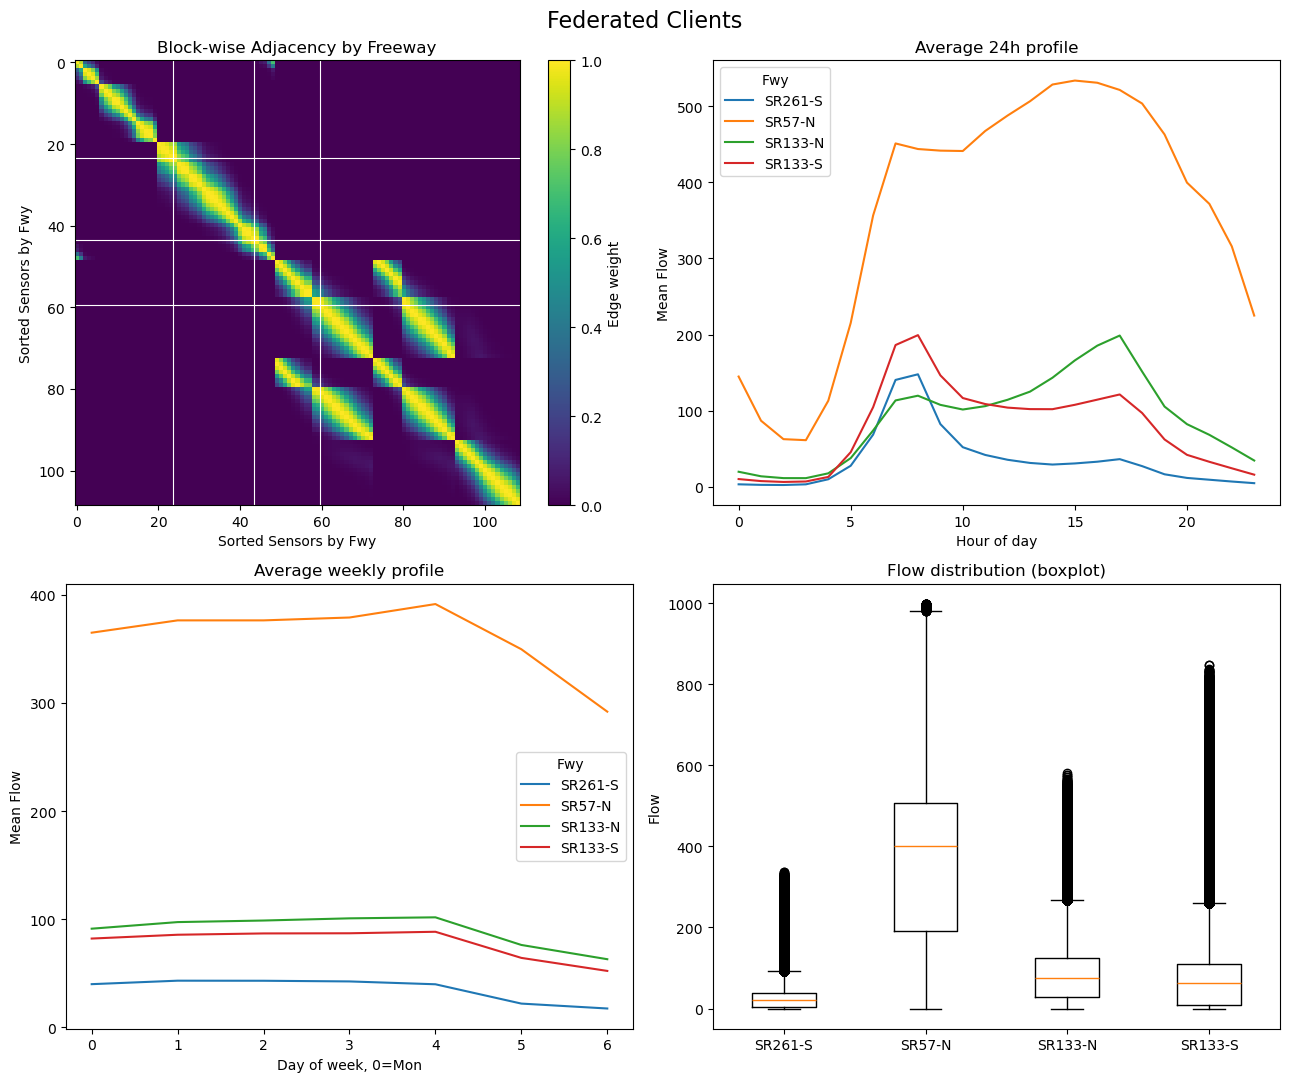

In [14]:
federated_fwy = ['SR261-S', 'SR57-N', 'SR133-N', 'SR133-S']
mean_flow_24h_federated = mean_flow(df, '24h', d12_sensor_to_fwy, federated_fwy)
mean_flow_week_federated = mean_flow(df, 'week', d12_sensor_to_fwy, federated_fwy)
graph(df,mean_flow_24h_federated, mean_flow_week_federated, d12_sensor_to_fwy, federated_fwy, 2)

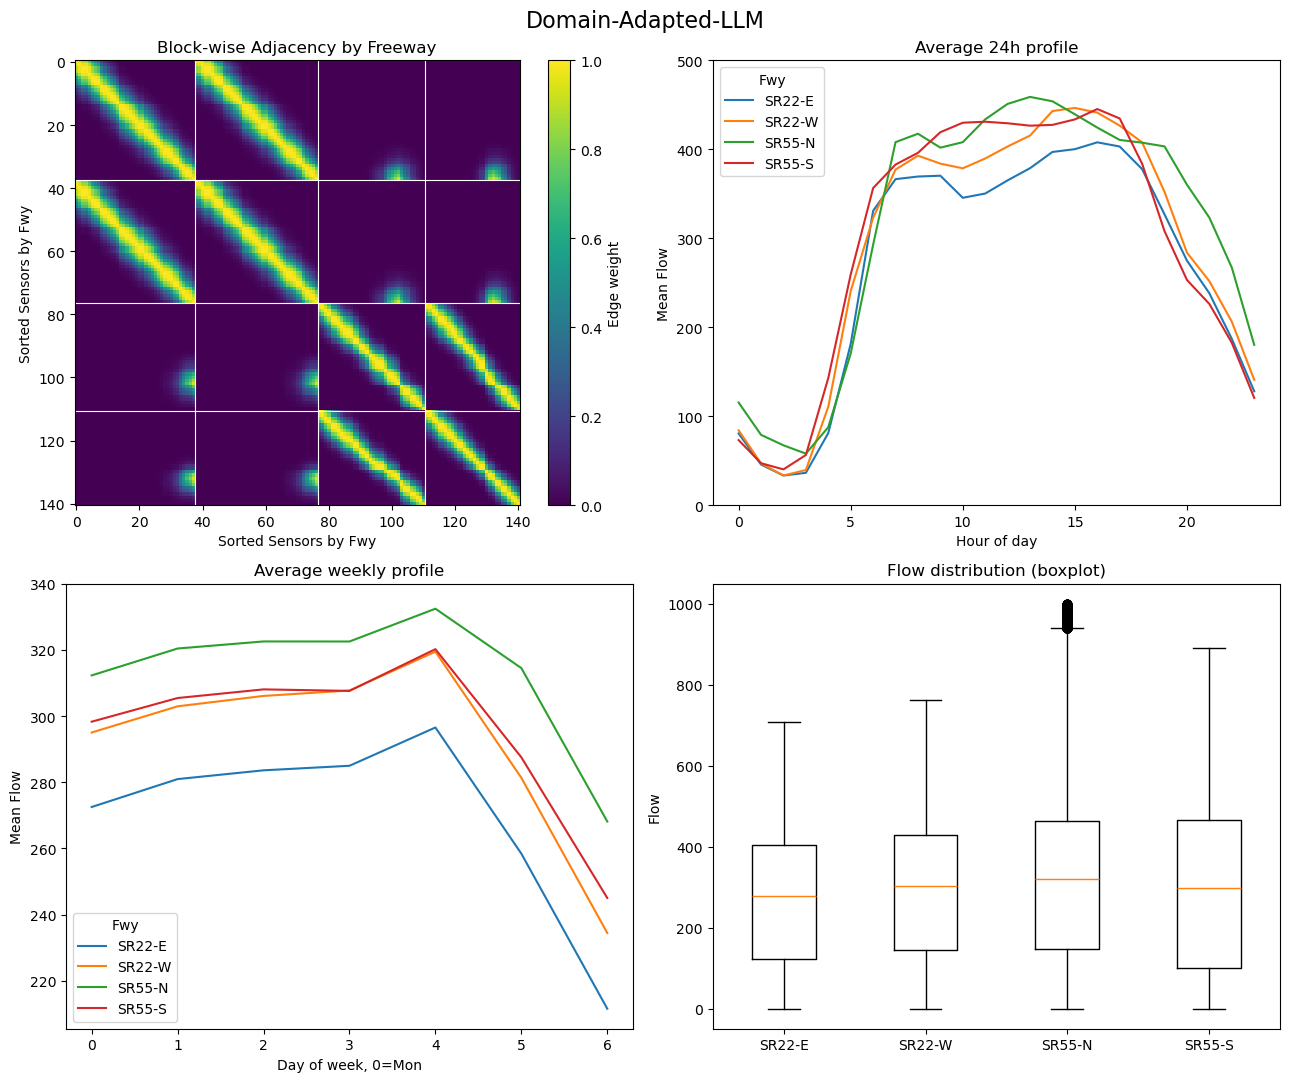

In [15]:
domain_fwy = ['SR22-E','SR22-W','SR55-N','SR55-S']
mean_flow_24h_domain = mean_flow(df, '24h', d12_sensor_to_fwy, domain_fwy)
mean_flow_week_domain = mean_flow(df, 'week', d12_sensor_to_fwy, domain_fwy)
graph(df,mean_flow_24h_domain, mean_flow_week_domain, d12_sensor_to_fwy, domain_fwy, 1)

In [ ]:
from datetime import datetime, timedelta
def get_prompt_stats(time_str, sensor):
    d12_fwy = domain.loc[domain['District'] == 12, 'Fwy'].unique().tolist() 
    domain_sensors, _, timestamps = extract_details(d12_fwy)
    A = np.load('data/ca_rn_adj.npy')
    order = pd.Index(domain['ID'].tolist())
    meta = domain.set_index('ID')
    i = order.get_loc(f'{sensor}')
    time = datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S")

    def degs(ids, diag=True):
        idx = order.get_indexer(pd.Index(ids))
        M = A[np.ix_(idx, idx)].copy()
        if not diag: np.fill_diagonal(M, 0)
        j = list(ids).index(f'{sensor}')
        return M[j].sum(), M[:, j].sum()

    def recent_readings(df, time, freq = 4):
        span = timedelta(minutes = 15 * freq)
        window = df.loc[time - span : time - timedelta(minutes = 15)]
        return window

    d12   = [s for s in order if s in meta.index and meta.loc[s,'District'] == 12]
    sel   = [s for s in d12 if meta.loc[s,'Fwy'] in ('SR22-E','SR22-W','SR55-N','SR55-S')]

    def get_congestion_ratio(z):
        return (z > 0.714 * z.max()).mean()

    def get_hourly_profile(s):
        return s.fillna(0).groupby(s.index.hour).mean()

    def weekly_profile(s):
        profile={}
        z=s.fillna(0)
        week = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
        for i in range(0,7):
            profile[week[i]] = list(z.groupby(z.index.dayofweek).mean())[i]
        return profile

    def slope(x, n):
        flow = x[-n:]
        return ((flow[-1]-flow[0])/(n-1))

    '''Static sensor context'''
    test = domain[domain['ID'] == f'{sensor}']
    District = list(test['District'])
    Country = list(test['County'])
    Lat = list(test['Lat'])
    Lng = list(test['Lng'])
    freeway = list(test['Fwy'])
    lanes = list(test['Lanes'])
    types = list(test['Type'])
    out_degree, in_degree = degs(sel)

    '''Statistical context'''
    testing_df = get_df(domain_sensors, timestamps, 2)
    testing = testing_df[f'{sensor}']
    mean = testing.mean()
    min_flow = testing.min()
    max_flow = testing.max()
    std = np.std(testing)
    congestion_ratio = get_congestion_ratio(testing.fillna(0))
    top_3_neighbour = [testing_df.columns[testing_df.columns.get_loc(f'{sensor}') + i] for i in range(1,4)]
    neighbour_recent_flows = {}
    for i in top_3_neighbour:
        neighbour_recent_flows[i] = list(recent_readings(testing_df[f'{i}'], time))
    hourly_profile = list(get_hourly_profile(testing))
    weekly_pattern = weekly_profile(testing)
    hourly_mean = hourly_profile[int(time.strftime("%H"))]

    '''Current time context'''
    past_12_flows = list(recent_readings(testing, time, 12))
    recent_trends = slope(past_12_flows, 4)
    net_change = past_12_flows[-1]-past_12_flows[-4]
    return (District, Country, Lat, Lng, freeway, lanes, types, out_degree, in_degree, 
                mean, min_flow, max_flow, std, congestion_ratio,top_3_neighbour,neighbour_recent_flows,hourly_profile, weekly_pattern, hourly_mean, 
                past_12_flows, recent_trends, net_change)

In [88]:
sensor = 1203303
time_str = '2019-07-10 04:15:00'

(District, Country, Lat, Lng, freeway, lanes, types, out_degree, in_degree, 
                mean, min_flow, max_flow, std, congestion_ratio,top_3_neighbour,neighbour_recent_flows,hourly_profile, weekly_pattern, hourly_mean, 
                past_12_flows, recent_trends, net_change) = get_prompt_stats(time_str, sensor)

user_prompt = f'''
    The following sensor information is provided:
    -location: Sensor ID {sensor}, District {District}, {Country}, California, USA.
    -Coordinates: Latitude {Lat}, Longitude {Lng}.
    -Freeway: {freeway} with {lanes} lanes, detector type {types}.
    -Range of observed flows: {min_flow}-{max_flow} vehicles / 15 min.
    -Spatial metrics: in_degree={in_degree}, out_degree={out_degree}.
    -Top neighbouring sensors: {top_3_neighbour}
    -Neighbour recent flows (last 1 hour): {neighbour_recent_flows}
    -Statistical summary: mean_flow={mean}, std_flow={std}, congestion_ratio={congestion_ratio}
    -Hourly profile (24-hour mean pattern): {hourly_profile}
    -Weekly pattern (vehicles/15 min): {weekly_pattern}
    -Typical hourly mean at this time: {hourly_mean} vehicles / 15 min 
    
    Current time context: 
    -Timestamp: {time_str} 
    -Past 12 flows: {past_12_flows}
    -Recent trend slope (last 4 points): {recent_trends} vehicles / 15 min
    -Net change over last 30 minutes: {net_change} vehicles  
    Task: Predict the traffic flow for the next 15, 30, 45 and 60 minutes and provide a comprehensive reasoning. Return your answer as valid JSON.'''

print(user_prompt)


    The following sensor information is provided:
    -location: Sensor ID 1203303, District [12], ['Orange'], California, USA.
    -Coordinates: Latitude [33.749859], Longitude [-117.831768].
    -Freeway: ['SR55-N'] with [4] lanes, detector type ['Mainline'].
    -Range of observed flows: 13.666666666666666-688.3333333333334 vehicles / 15 min.
    -Spatial metrics: in_degree=7.8296271748639334, out_degree=8.80595418040258.
    -Top neighbouring sensors: ['1203331', '1203342', '1215811']
    -Neighbour recent flows (last 1 hour): {'1203331': [32.333333333333336, 32.0, 38.666666666666664, 38.333333333333336], '1203342': [47.333333333333336, 48.333333333333336, 52.333333333333336, 53.333333333333336], '1215811': [0.0, 23.0, 111.0, 0.0]}
    -Statistical summary: mean_flow=337.64378585446866, std_flow=188.34488065694245, congestion_ratio=0.2717391304347826
    -Hourly profile (24-hour mean pattern): [103.7721920289855, 60.99773550724638, 46.375, 39.31884057971015, 67.09239130434783, 147

In [137]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()
client = OpenAI()
model = os.getenv('model')
effort = os.getenv('effort')

def traffic_prediction(time_str, sensor, system_prompt, effort):
    (District, Country, Lat, Lng, freeway, lanes, types, out_degree, in_degree, 
        mean, min_flow, max_flow, std, congestion_ratio,top_3_neighbour,neighbour_recent_flows,hourly_profile, weekly_pattern, hourly_mean, 
        past_12_flows, recent_trends, net_change) = get_prompt_stats(time_str, sensor)

    user_prompt = f'''
    The following sensor information is provided:
    -location: Sensor ID {sensor}, District {District}, {Country}, California, USA.
    -Coordinates: Latitude {Lat}, Longitude {Lng}.
    -Freeway: {freeway} with {lanes} lanes, detector type {types}.
    -Range of observed flows: {min_flow}-{max_flow} vehicles / 15 min.
    -Spatial metrics: in_degree={in_degree}, out_degree={out_degree}.
    -Top neighbouring sensors: {top_3_neighbour}
    -Neighbour recent flows (last 1 hour): {neighbour_recent_flows}
    -Statistical summary: mean_flow={mean}, std_flow={std}, congestion_ratio={congestion_ratio}
    -Hourly profile (24-hour mean pattern): {hourly_profile}
    -Weekly pattern (vehicles/15 min): {weekly_pattern}
    -Typical hourly mean at this time: {hourly_mean} vehicles / 15 min 
    
    Current time context: 
    -Timestamp: {time_str} 
    -Past 12 flows: {past_12_flows}
    -Recent trend slope (last 4 points): {recent_trends} vehicles / 15 min
    -Net change over last 30 minutes: {net_change} vehicles  
    Task: Predict the traffic flow for the next 15, 30, 45 and 60 minutes and provide a comprehensive reasoning. Return your answer as valid JSON.'''

    response = client.responses.create(
        model=model,
        reasoning={"effort": effort},
        input=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    )

    return response.output_text, user_prompt

system_prompt = '''
    You are an expert traffic flow prediction model that forecasts short-term freeway traffic flow based on spatio-temporal information. 
    You receive structured traffic data including sensor metadata, spatial neighbour information, statistical summaries, and historical flow sequences. 
    Your task is to perform multi-step short-term traffic flow prediction for the next 15, 30, 45, and 60 minutes. 
    Predictions should follow realistic temporal continuity and reflect monotonic trends when supported by historical data. 
    Return a JSON object containing predicted_flow, avg_future_flow, trend_change, Interval-wise Explanation, Concise Analytical Explanation, Step-by-step Explanation, and metadata.'''

response, user_prompt = traffic_prediction('2019-07-10 04:15:00', 1203303, system_prompt, effort)
print(response)

{
  "predicted_flow": {
    "15_minutes": 55.0,
    "30_minutes": 66.0,
    "45_minutes": 82.0,
    "60_minutes": 103.0
  },
  "avg_future_flow": 76.5,
  "trend_change": {
    "from_current_flow": 47.33,
    "to_60_minute_flow": 103.0,
    "absolute_change": 55.67,
    "percentage_change": 117.6,
    "direction": "increasing",
    "pattern": "Gradual acceleration toward the morning peak period"
  },
  "Interval-wise Explanation": {
    "15_minutes": "The recent four-point slope is positive at 3 vehicles per 15 minutes, so flow is expected to rise modestly from the current 47.33 vehicles per 15 minutes. The forecast remains below the typical 04:00 hourly mean but begins moving toward the morning ramp.",
    "30_minutes": "Flow is projected to increase further as the timestamp approaches 05:00. The recent net gain of 9 vehicles over 30 minutes and the upward hourly profile support a value near 66 vehicles per 15 minutes.",
    "45_minutes": "The historical hourly pattern shows a substant

In [188]:
import numpy as np, pandas as pd

train = get_df(domain_sensors, timestamps, 1)[str(sensor)].fillna(0)
test  = get_df(domain_sensors, timestamps, 2)[str(sensor)].fillna(0)
profile = train.groupby(train.index.hour).mean()

In [140]:
def score(y, yhat, mape_floor=10):
    e = yhat - y
    m = y > mape_floor
    return dict(RMSE=np.sqrt((e**2).mean()),
                    MAE=np.abs(e).mean(),
                    MAPE=100*np.abs(e[m]/y[m]).mean(),
                    R2=1 - (e**2).sum()/((y-y.mean())**2).sum())

def historical_average_baseline(test, profile):
    rows = {}
    before={}
    after={}
    for k in (1,2,3,4):
        tgt   = test.index + pd.Timedelta(minutes=15*k)
        tgt   = tgt[tgt.isin(test.index)]
        y     = test.reindex(tgt).to_numpy()
        yhat  = profile.reindex(tgt.hour).to_numpy()
        rows[f'{15*k}min'] = score(y, yhat)
        before[f'{15*k}min'] = y
        after [f'{15*k}min'] = yhat

    return pd.DataFrame(rows).T, before, after

rows, before, after = historical_average_baseline(test, profile)

In [141]:
rows

,RMSE,MAE,MAPE,R2
15min,71.232599,51.604489,22.803615,0.856957
30min,71.234611,51.607211,22.804682,0.856943
45min,71.236369,51.608689,22.803817,0.856928
60min,71.237817,51.609468,22.801188,0.856912


In [231]:
import json
from pathlib import Path

def zero_shot_llm_baseline(
    test,
    train,
    sensor,
    *,
    batch_size=24,
    checkpoint_path="llm_yhat_result.json",
    resume=True,
):
    """
    Returns:
        {
            "15min": [response_text, ...],
            "30min": [response_text, ...],
            "45min": [response_text, ...],
            "60min": [response_text, ...],
        }
    """
    checkpoint_path = Path(checkpoint_path)

    if resume and checkpoint_path.exists():
        yhat_by_horizon = json.loads(checkpoint_path.read_text(encoding="utf-8"))
    else:
        yhat_by_horizon = {}

    profile = train.groupby(train.index.hour).mean()
    profile_text = "\n".join(
        f"hour {hour:02d}:00 average = {value:.4f}"
        for hour, value in profile.items()
    )

    def save_checkpoint():
        temporary_path = checkpoint_path.with_suffix(
            f"{checkpoint_path.suffix}.tmp"
        )
        temporary_path.write_text(
            json.dumps(yhat_by_horizon, indent=2),
            encoding="utf-8",
        )
        temporary_path.replace(checkpoint_path)

    for minutes in (15, 30, 45, 60):
        label = f"{minutes}min"
        horizon = pd.Timedelta(minutes=minutes)

        target_index = test.index + horizon
        target_index = target_index[target_index.isin(test.index)]

        total_batches = (len(target_index) + batch_size - 1) // batch_size
        responses = yhat_by_horizon.get(label, [])

        for batch_number, start in enumerate(
            range(0, len(target_index), batch_size),
            start=1,
        ):
            # Already written to the checkpoint in an earlier run.
            if batch_number <= len(responses):
                continue

            target_batch = target_index[start:start + batch_size]
            target_text = "\n".join(
                timestamp.strftime("%Y-%m-%d %H:%M:%S")
                for timestamp in target_batch
            )

            prompt = f"""You forecast traffic flow for sensor {sensor}.
                            Historical hourly averages from the training period:
                            {profile_text}

                            Forecast horizon: {minutes} minutes.
                            Target timestamps, in order:
                            {target_text}

                            Return exactly {len(target_batch)} numeric predictions as a Python list.
                            Use only the training information given. Return no other text.
                            """

            response = client.responses.create(
                model="gpt-4o-mini-2024-07-18",
                input=[{"role": "user", "content": prompt}],
            )

            responses.append(response.output_text)
            yhat_by_horizon[label] = responses
            save_checkpoint()

            print(
                f"{label}: batch {batch_number}/{total_batches}",
                flush=True,
            )

        yhat_by_horizon[label] = responses
        save_checkpoint()

    return yhat_by_horizon

In [228]:
# Locked: never uncomment this costly LLM call unless you deliberately want a fresh run.
# yhat = zero_shot_llm_baseline(test, train, sensor)

# Restore the 736 saved LLM responses from this notebook's existing output; no API call.
from ast import literal_eval
from json import load
from pathlib import Path

with Path('main.ipynb').open(encoding='utf-8') as notebook_file:
    notebook = load(notebook_file)

saved_yhat_cell = next(cell for cell in notebook['cells'] if cell.get('id') == '9f852db5')
saved_yhat = saved_yhat_cell['outputs'][0]['data']['text/plain']
yhat = literal_eval(''.join(saved_yhat))
print(f'Restored {len(yhat)} saved LLM responses into yhat; no LLM request was made.')

Restored 736 saved LLM responses into yhat; no LLM request was made.


In [229]:
yhat

['```python\npredictions = [\n    55.7067, 55.7067, 55.7067, 55.7067, 43.8315, 43.8315, 43.8315, 43.8315,\n    36.4392, 36.4392, 36.4392, 36.4392, 61.4507, 61.4507, 61.4507, 61.4507,\n    143.4609, 143.4609, 143.4609, 143.4609, 267.2859, 267.2859, 267.2859,\n    267.2859\n]\n```',
 '```python\npredictions = [\n    394.0543,  # 2019-07-01 07:00:00\n    394.0543,  # 2019-07-01 07:15:00\n    394.0543,  # 2019-07-01 07:30:00\n    394.0543,  # 2019-07-01 07:45:00\n    417.7288,  # 2019-07-01 08:00:00\n    417.7288,  # 2019-07-01 08:15:00\n    417.7288,  # 2019-07-01 08:30:00\n    417.7288,  # 2019-07-01 08:45:00\n    403.2684,  # 2019-07-01 09:00:00\n    403.2684,  # 2019-07-01 09:15:00\n    403.2684,  # 2019-07-01 09:30:00\n    403.2684,  # 2019-07-01 09:45:00\n    422.8407,  # 2019-07-01 10:00:00\n    422.8407,  # 2019-07-01 10:15:00\n    422.8407,  # 2019-07-01 10:30:00\n    422.8407,  # 2019-07-01 10:45:00\n    470.6593,  # 2019-07-01 11:00:00\n    470.6593,  # 2019-07-01 11:15:00\n    

In [230]:
# Parse, organise, and score saved LLM forecasts.  This makes no API calls.
import re
from ast import literal_eval

HORIZONS_MINUTES = (15, 30, 45, 60)

def _parse_llm_prediction_list(response):
    """Extract the numeric list from one saved LLM response."""
    match = re.search(r'predictions\s*=\s*(\[.*?\])', response, flags=re.IGNORECASE | re.DOTALL)
    if match is None:
        match = re.search(r'(\[.*?\])', response, flags=re.DOTALL)
    if match is None:
        raise ValueError('No Python-style prediction list found in an LLM response.')

    # Timestamp comments inside the LLM response are valid for humans but not literal_eval.
    prediction_literal = re.sub(r'#.*$', '', match.group(1), flags=re.MULTILINE)
    return np.asarray(literal_eval(prediction_literal), dtype=float)

def _responses_for_horizon(yhat, horizon_minutes, legacy_horizon=60):
    """Support both the new {"15min": [...], ...} structure and legacy flat yhat."""
    if isinstance(yhat, dict):
        for key in (f'{horizon_minutes}min', f'{horizon_minutes} min', horizon_minutes):
            if key in yhat:
                return yhat[key]
        return None
    return yhat if horizon_minutes == legacy_horizon else None

def _score_available_predictions(y, yhat, mape_floor=10):
    valid = np.isfinite(y) & np.isfinite(yhat)
    y, yhat = y[valid], yhat[valid]
    if len(y) == 0:
        return dict(RMSE=np.nan, MAE=np.nan, MAPE=np.nan, R2=np.nan, N=0, Coverage=0.0)

    error = yhat - y
    mape_valid = y > mape_floor
    return dict(
        RMSE=np.sqrt((error ** 2).mean()),
        MAE=np.abs(error).mean(),
        MAPE=100 * np.abs(error[mape_valid] / y[mape_valid]).mean() if mape_valid.any() else np.nan,
        R2=1 - (error ** 2).sum() / ((y - y.mean()) ** 2).sum(),
        N=len(y),
        Coverage=valid.mean(),
    )

def organise_llm_yhat(yhat, test, horizons=HORIZONS_MINUTES, batch_size=24):
    """Return LLM scores, aligned forecasts, and batch-quality diagnostics by horizon.

    Each LLM response is aligned to its original 24-timestamp batch. Extra values are
    ignored; missing values remain NaN so the reported coverage is explicit.
    """
    metrics, predictions, diagnostics = {}, {}, []

    for minutes in horizons:
        label = f'{minutes}min'
        target_index = test.index + pd.Timedelta(minutes=minutes)
        target_index = target_index[target_index.isin(test.index)]
        actual = test.reindex(target_index).to_numpy(dtype=float)
        responses = _responses_for_horizon(yhat, minutes)

        if responses is None:
            metrics[label] = dict(RMSE=np.nan, MAE=np.nan, MAPE=np.nan, R2=np.nan, N=0, Coverage=0.0, Status='not saved')
            continue

        batch_sizes = [min(batch_size, len(actual) - start) for start in range(0, len(actual), batch_size)]
        if len(responses) != len(batch_sizes):
            raise ValueError(f'{label}: expected {len(batch_sizes)} batches, found {len(responses)}.')

        forecast = np.full(len(actual), np.nan, dtype=float)
        offset = 0
        for batch_number, (response, expected_size) in enumerate(zip(responses, batch_sizes), start=1):
            parsed = _parse_llm_prediction_list(response)
            used = min(len(parsed), expected_size)
            forecast[offset:offset + used] = parsed[:used]
            if len(parsed) != expected_size:
                diagnostics.append(dict(Horizon=label, Batch=batch_number, Expected=expected_size, Received=len(parsed), Used=used))
            offset += expected_size

        predictions[label] = pd.Series(forecast, index=target_index, name=label)
        metrics[label] = _score_available_predictions(actual, forecast) | {'Status': 'complete'}

    return pd.DataFrame(metrics).T, predictions, pd.DataFrame(diagnostics)

llm_scores, llm_predictions, llm_diagnostics = organise_llm_yhat(yhat, test)
ha_scores = rows.reindex([f'{minutes}min' for minutes in HORIZONS_MINUTES]).copy()
ha_scores['N'] = [len(test.index[(test.index + pd.Timedelta(minutes=minutes)).isin(test.index)]) for minutes in HORIZONS_MINUTES]
ha_scores['Coverage'] = 1.0
ha_scores['Status'] = 'complete'
comparison = pd.concat({'HA': ha_scores, 'LLM': llm_scores}, names=['Model', 'Horizon'])
comparison

RMSE        MAE       MAPE        R2      N Coverage  \
Model Horizon                                                              
HA    15min    71.232599  51.604489  22.803615  0.856957  17663      1.0   
      30min    71.234611  51.607211  22.804682  0.856943  17662      1.0   
      45min    71.236369  51.608689  22.803817  0.856928  17661      1.0   
      60min    71.237817  51.609468  22.801188  0.856912  17660      1.0   
LLM   15min          NaN        NaN        NaN       NaN      0      0.0   
      30min          NaN        NaN        NaN       NaN      0      0.0   
      45min          NaN        NaN        NaN       NaN      0      0.0   
      60min    95.594305  64.801093  26.985871  0.742335  17654  0.99966   

                  Status  
Model Horizon             
HA    15min     complete  
      30min     complete  
      45min     complete  
      60min     complete  
LLM   15min    not saved  
      30min    not saved  
      45min    not saved  
      60min     complete

In [225]:
yhat

['```python\npredictions = [\n    55.7067, 55.7067, 55.7067, 55.7067, 43.8315, 43.8315, 43.8315, 43.8315,\n    36.4392, 36.4392, 36.4392, 36.4392, 61.4507, 61.4507, 61.4507, 61.4507,\n    143.4609, 143.4609, 143.4609, 143.4609, 267.2859, 267.2859, 267.2859,\n    267.2859\n]\n```',
 '```python\npredictions = [\n    394.0543,  # 2019-07-01 07:00:00\n    394.0543,  # 2019-07-01 07:15:00\n    394.0543,  # 2019-07-01 07:30:00\n    394.0543,  # 2019-07-01 07:45:00\n    417.7288,  # 2019-07-01 08:00:00\n    417.7288,  # 2019-07-01 08:15:00\n    417.7288,  # 2019-07-01 08:30:00\n    417.7288,  # 2019-07-01 08:45:00\n    403.2684,  # 2019-07-01 09:00:00\n    403.2684,  # 2019-07-01 09:15:00\n    403.2684,  # 2019-07-01 09:30:00\n    403.2684,  # 2019-07-01 09:45:00\n    422.8407,  # 2019-07-01 10:00:00\n    422.8407,  # 2019-07-01 10:15:00\n    422.8407,  # 2019-07-01 10:30:00\n    422.8407,  # 2019-07-01 10:45:00\n    470.6593,  # 2019-07-01 11:00:00\n    470.6593,  # 2019-07-01 11:15:00\n    

In [200]:
print(train.to_string())

2019-01-01 00:00:00     77.333333
2019-01-01 00:15:00    189.666667
2019-01-01 00:30:00    216.333333
2019-01-01 00:45:00    217.000000
2019-01-01 01:00:00    194.333333
2019-01-01 01:15:00    197.000000
2019-01-01 01:30:00    164.333333
2019-01-01 01:45:00    142.666667
2019-01-01 02:00:00    127.000000
2019-01-01 02:15:00    115.333333
2019-01-01 02:30:00    107.666667
2019-01-01 02:45:00     98.000000
2019-01-01 03:00:00     89.333333
2019-01-01 03:15:00     68.000000
2019-01-01 03:30:00     58.333333
2019-01-01 03:45:00     39.666667
2019-01-01 04:00:00     44.000000
2019-01-01 04:15:00     38.333333
2019-01-01 04:30:00     35.666667
2019-01-01 04:45:00     37.000000
2019-01-01 05:00:00     37.666667
2019-01-01 05:15:00     42.000000
2019-01-01 05:30:00     47.333333
2019-01-01 05:45:00     62.333333
2019-01-01 06:00:00     58.333333
2019-01-01 06:15:00     59.000000
2019-01-01 06:30:00     72.000000
2019-01-01 06:45:00     81.333333
2019-01-01 07:00:00     72.333333
2019-01-01 07: